# SWIS Data & CME Labels — Preprocessing Pipeline

**Goal:** Load Aditya-L1 SWIS `.cdf` files + CME label CSVs, merge them on a
common time axis, engineer solar-wind features, and export a clean
`training_dataset.csv` ready for ML models.

---
### Data Sources
| Source | Path | Description |
|--------|------|-------------|
| SWIS CDF files | `Dataset/raw/swis/` | Aditya-L1 Level-1 AUX solar-wind ion spectrometer data |
| CME Labels 2021–2024 | `Dataset/raw/cme_labels_2021_2024.csv` | CME catalogue with halo flag |
| CME Labels 2024–2025 | `Dataset/raw/cme_labels_2024_2025.csv` | CME catalogue with halo flag |
| Solar Wind CSV | `Dataset/raw/solar_wind_2021_2024.csv` | Pre-extracted solar-wind parameters |

### Pipeline Steps
1. **Load & Inspect** — read all sources, verify shapes & dtypes
2. **SWIS CDF Processing** — extract key variables from each daily CDF file
3. **CME Label Merging** — combine both CME catalogues, derive binary labels
4. **Time Alignment** — resample / merge SWIS + solar-wind onto CME time axis
5. **Feature Engineering** — derived ratios, rolling stats, magnetic field magnitude
6. **Quality Checks** — missing-value analysis, class-balance, correlation heatmap
7. **Train/Val/Test Split** — chronological split preserving time order
8. **Export** — save processed datasets to `Dataset/processed/`

> **Memory note:** Each raw CDF file has ~34 000 sub-second records (×18 cols = ~5 MB).
> Loading all 700+ files raw before concatenating would require **~14 GB** of RAM.
> The pipeline avoids this by **resampling each file to hourly (24 rows) inside the loop**
> before appending — total memory stays under 50 MB for the SWIS portion.


## 0 — Install / Import Dependencies

In [2]:
# ── Install any missing packages ────────────────────────────────────────────
import subprocess, sys

REQUIRED = [
    'cdflib',      # read NASA CDF files
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'tqdm',
]

for pkg in REQUIRED:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('All packages available ✓')

Installing scikit-learn...
All packages available ✓


In [3]:
import os
import gc
import glob
import warnings
import re
import pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import cdflib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Imports OK ✓')

Imports OK ✓


In [4]:
# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR   = Path(r'D:\SOLAR-HALOS-FORECASTING&NOWCASTING\Project-Code\Dataset')
RAW_DIR    = BASE_DIR / 'raw'
SWIS_DIR   = RAW_DIR / 'swis'
PROC_DIR   = BASE_DIR / 'processed'
PROC_DIR.mkdir(parents=True, exist_ok=True)

CME_2021_PATH = RAW_DIR / 'cme_labels_2021_2024.csv'
CME_2024_PATH = RAW_DIR / 'cme_labels_2024_2025.csv'
SW_CSV_PATH   = RAW_DIR / 'solar_wind_2021_2024.csv'

for p in [CME_2021_PATH, CME_2024_PATH, SW_CSV_PATH, SWIS_DIR]:
    status = '✓' if p.exists() else '✗ MISSING'
    print(f'{status}  {p}')

✓  D:\SOLAR-HALOS-FORECASTING&NOWCASTING\Project-Code\Dataset\raw\cme_labels_2021_2024.csv
✓  D:\SOLAR-HALOS-FORECASTING&NOWCASTING\Project-Code\Dataset\raw\cme_labels_2024_2025.csv
✓  D:\SOLAR-HALOS-FORECASTING&NOWCASTING\Project-Code\Dataset\raw\solar_wind_2021_2024.csv
✓  D:\SOLAR-HALOS-FORECASTING&NOWCASTING\Project-Code\Dataset\raw\swis


---
## 1 — Load & Inspect CSV Sources

In [5]:
# ── Load solar wind CSV ──────────────────────────────────────────────────────
sw_df = pd.read_csv(SW_CSV_PATH, parse_dates=['timestamp'])
sw_df.set_index('timestamp', inplace=True)
sw_df.sort_index(inplace=True)
sw_df.index = sw_df.index.tz_localize(None)

print('Solar Wind CSV shape:', sw_df.shape)
print('Date range:', sw_df.index.min(), '→', sw_df.index.max())
sw_df.head()

Solar Wind CSV shape: (35064, 9)
Date range: 2021-01-01 00:00:00 → 2024-12-31 23:00:00


,bx_gse,by_gse,bz_gse,by_gsm,bz_gsm,proton_density,plasma_speed_kmps,flow_pressure_npa,plasma_temperature_k
timestamp,,,,,,,,,
2021-01-01 00:00:00,-1.1000,1.9000,-1.5000,1.6000,0.1000,365.0000,-1.3000,-1.2000,1.1700
2021-01-01 01:00:00,-1.4000,1.9000,-1.8000,1.5000,0.1000,366.0000,-0.6000,-1.6000,1.1700
2021-01-01 02:00:00,-2.1000,0.1000,-2.1000,-0.3000,0.3000,360.0000,-1.3000,-2.6000,1.1200
2021-01-01 03:00:00,-1.5000,2.0000,-1.8000,1.8000,0.2000,358.0000,-0.6000,-1.6000,1.0500
2021-01-01 04:00:00,-1.7000,1.7000,-1.9000,1.5000,0.2000,356.0000,-0.7000,-1.8000,1.0500


In [6]:
# ── Load CME labels ──────────────────────────────────────────────────────────
def load_cme(path):
    df = pd.read_csv(path)
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    elif 'date' in df.columns and 'time' in df.columns:
        df['timestamp'] = pd.to_datetime(
            df['date'].astype(str) + ' ' + df['time'].astype(str),
            format='mixed', dayfirst=False
        )
        df.drop(columns=['date', 'time'], errors='ignore', inplace=True)
    df.set_index('timestamp', inplace=True)
    df.sort_index(inplace=True)
    return df

cme_early = load_cme(CME_2021_PATH)
cme_late  = load_cme(CME_2024_PATH)

print('CME 2021–2024 shape:', cme_early.shape)
print('CME 2024–2025 shape:', cme_late.shape)
display(cme_early.head(3))
display(cme_late.head(3))

CME 2021–2024 shape: (6524, 5)
CME 2024–2025 shape: (4206, 9)


,central_pa,angular_width,speed_kmps,is_halo,label
timestamp,,,,,
2021-01-01 00:12:05,239,28,128,0,0
2021-01-01 02:48:06,68,20,233,0,0
2021-01-01 22:00:05,226,127,190,0,0


,date,time,central_pa,angular_width,speed_kmps,is_halo,label,source_year,source_month
timestamp,,,,,,,,,
2024-01-01 15:12:09,2024/01/01,15:12:09,65,51,286,0,0,2024,1
2024-01-01 16:36:05,2024/01/01,16:36:05,146,66,403,0,0,2024,1
2024-01-01 17:00:05,2024/01/01,17:00:05,52,25,243,0,0,2024,1


In [7]:
# ── Combine CME catalogues ───────────────────────────────────────────────────
common_cols = list(set(cme_early.columns) & set(cme_late.columns))
cme_all = pd.concat([cme_early[common_cols], cme_late[common_cols]], axis=0)
cme_all = cme_all[~cme_all.index.duplicated(keep='first')]
cme_all.sort_index(inplace=True)

print('Combined CME catalogue shape:', cme_all.shape)
print('Date range:', cme_all.index.min(), '→', cme_all.index.max())
display(cme_all.describe())

Combined CME catalogue shape: (8426, 5)
Date range: 2021-01-01 00:12:05 → 2025-12-31 21:48:07


,is_halo,label
count,8426.0000,8426.0000
mean,0.0335,0.0335
std,0.1799,0.1799
min,0.0000,0.0000
25%,0.0000,0.0000
50%,0.0000,0.0000
75%,0.0000,0.0000
max,1.0000,1.0000


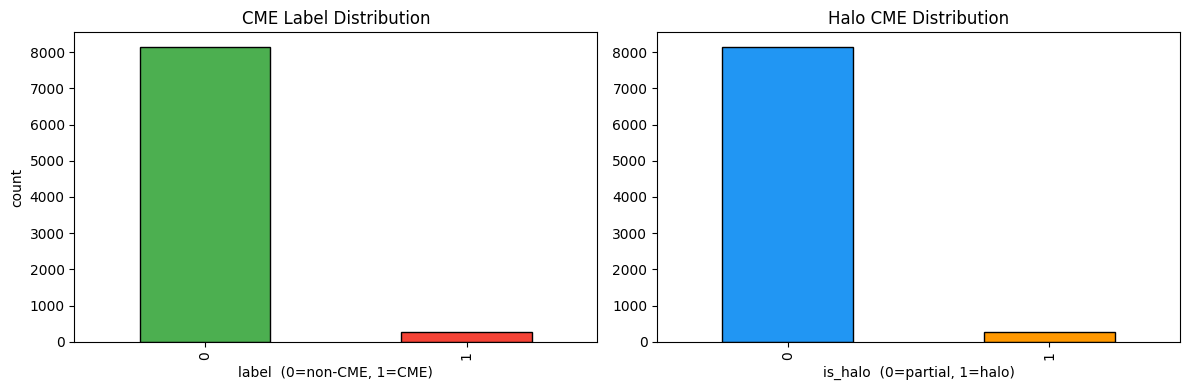

Positive-class fraction (CME): 3.35%


In [8]:
# ── Label distribution ───────────────────────────────────────────────────────
label_counts = cme_all['label'].value_counts().sort_index()
halo_counts  = cme_all['is_halo'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label_counts.plot(kind='bar', ax=axes[0], color=['#4CAF50', '#F44336'],
                  edgecolor='black', title='CME Label Distribution')
axes[0].set_xlabel('label  (0=non-CME, 1=CME)')
axes[0].set_ylabel('count')
halo_counts.plot(kind='bar', ax=axes[1], color=['#2196F3', '#FF9800'],
                 edgecolor='black', title='Halo CME Distribution')
axes[1].set_xlabel('is_halo  (0=partial, 1=halo)')
plt.tight_layout()
plt.show()

pos_frac = label_counts.get(1, 0) / label_counts.sum()
print(f'Positive-class fraction (CME): {pos_frac:.2%}')

---
## 2 — Load SWIS CDF Files

> **Data product:** The CDF files here are **Level-1 AUX (housekeeping)** files  
> (`AL1_ASW91_L1_AUX_*`). They contain detector count rates, spacecraft position/velocity,  
> pointing angles and hardware monitoring. Derived plasma parameters (speed, density,  
> temperature) are in higher-level products; the solar-wind CSV covers those for 2021-2024.
>
> **Memory strategy:** Each raw file has ~34 000 sub-second rows × 18 cols ≈ 5 MB.  
> Loading 700 files raw before `pd.concat` would need ~14 GB RAM.  
> ✅ **We resample each file to hourly (24 rows) _inside_ the loop** before appending,  
> keeping peak RAM under ~100 MB for the SWIS portion.

In [9]:
# ── Discover CDF files — keep latest version per day ─────────────────────────
all_cdf = sorted(glob.glob(str(SWIS_DIR / '*.cdf')))
print(f'Total CDF files found: {len(all_cdf)}')

date_to_file = defaultdict(list)
DATE_RE = re.compile(r'(\d{8})_UNP.*?(V\d+)\.cdf$')
for fp in all_cdf:
    m = DATE_RE.search(os.path.basename(fp))
    if m:
        date_to_file[m.group(1)].append((m.group(2), fp))

unique_cdf = [sorted(v)[-1][1] for v in date_to_file.values()]
unique_cdf.sort()
print(f'Unique days after deduplication: {len(unique_cdf)}')
print('First:', os.path.basename(unique_cdf[0]))
print('Last :', os.path.basename(unique_cdf[-1]))

Total CDF files found: 709
Unique days after deduplication: 694
First: AL1_ASW91_L1_AUX_20240102_UNP_9999_999999_V01.cdf
Last : AL1_ASW91_L1_AUX_20251230_UNP_9999_999999_V01.cdf


In [10]:
# ── Peek at one CDF to confirm variable names ────────────────────────────────
sample_cdf = cdflib.CDF(unique_cdf[0])
cdf_info   = sample_cdf.cdf_info()

print('=== CDF Variables ===')
for v in cdf_info.zVariables:
    try:
        shape = sample_cdf.varget(v).shape
    except Exception:
        shape = '?'
    print(f'  {v:40s}  shape={shape}')

=== CDF Variables ===
  obs_time                                  shape=(34446, 5)
  epoch_for_cdf                             shape=(34446, 5)
  fpga_ticks                                shape=(34446,)
  frame_num                                 shape=(34446,)
  last_comm_fpga                            shape=(34446, 4)
  trig_counts                               shape=(34446, 5, 2, 5)
  coin_trig_counts                          shape=(34446, 5, 5)
  peak_det_counts                           shape=(34446, 5, 5)
  rej_counts                                shape=(34446, 5, 5)
  fpga_temp_mon                             shape=(34446,)
  fpga_core_volt_mon                        shape=(34446,)
  fpga_io_volt_mon                          shape=(34446,)
  FEE_volt_mon                              shape=(34446, 4)
  DC_temp_mon                               shape=(34446, 3)
  HV_pack_mon                               shape=(34446, 2)
  ESA1_HV_set                               shape=(34446, 

In [11]:
# ── CDF variable configuration ───────────────────────────────────────────────
#
# Time variables in this CDF:
#   epoch_for_cdf  (N, 5) : CDF_EPOCH ms since J2000 — one per energy step
#   obs_time       (N, 5) : Unix timestamp in seconds
# We use epoch_for_cdf[:,0] as the primary time axis.

TIME_VAR = 'epoch_for_cdf'
UNIX_VAR = 'obs_time'

SWIS_SCALAR_VARS = [
    # Detector count rates  (multi-dim → summed inside extractor)
    'trig_counts',
    'coin_trig_counts',
    'peak_det_counts',
    'rej_counts',
    'coinc_trig_count_total',
    # Housekeeping scalars
    'fpga_temp_mon',
    'fpga_core_volt_mon',
    'fpga_io_volt_mon',
    'pile_up_time',
    # Spacecraft position (GSE, km)
    'spacecraft_xpos',
    'spacecraft_ypos',
    'spacecraft_zpos',
    # Spacecraft velocity (GSE, km/s)
    'spacecraft_xvel',
    'spacecraft_yvel',
    'spacecraft_zvel',
    # Pointing angles (degrees)
    'angle_xgse',
    'angle_ygse',
    'angle_zgse',
]

available_vars = cdf_info.zVariables
SCALAR_VARS = [v for v in SWIS_SCALAR_VARS if v in available_vars]
print(f'Time variable        : {TIME_VAR}')
print(f'Variables to extract : {len(SCALAR_VARS)}')
print(SCALAR_VARS)

Time variable        : epoch_for_cdf
Variables to extract : 18
['trig_counts', 'coin_trig_counts', 'peak_det_counts', 'rej_counts', 'coinc_trig_count_total', 'fpga_temp_mon', 'fpga_core_volt_mon', 'fpga_io_volt_mon', 'pile_up_time', 'spacecraft_xpos', 'spacecraft_ypos', 'spacecraft_zpos', 'spacecraft_xvel', 'spacecraft_yvel', 'spacecraft_zvel', 'angle_xgse', 'angle_ygse', 'angle_zgse']


In [22]:
# ── Extractor helpers ─────────────────────────────────────────────────────────

def _parse_epoch(cdf, time_var=TIME_VAR, unix_var=UNIX_VAR):
    """
    Parse the time axis from a SWIS CDF file.
    Prefers CDF_EPOCH (epoch_for_cdf[:,0]), falls back to Unix seconds (obs_time).
    cdflib >= 1.3: to_datetime() has no 'to_np' kwarg — wrap result in np.asarray().
    """
    avail = cdf.cdf_info().zVariables
    if time_var in avail:
        raw = cdf.varget(time_var)
        if raw.ndim > 1:
            raw = raw[:, 0]            # (N,5) → (N,)
        dt64 = np.asarray(cdflib.cdfepoch.to_datetime(raw))
        return pd.DatetimeIndex(dt64).tz_localize(None)
    elif unix_var in avail:
        raw = cdf.varget(unix_var)
        if raw.ndim > 1:
            raw = raw[:, 0]
        return pd.to_datetime(raw, unit='s', utc=False)
    return None


def extract_daily_cdf(filepath, scalar_vars):
    """
    Open one SWIS CDF, extract scalar variables and return a DataFrame
    **already resampled to hourly mean** to keep memory usage low.

    Raw records  : ~34 000  (sub-second cadence)
    After resample:      24  (one row per hour)
    """
    try:
        cdf   = cdflib.CDF(filepath)
        avail = cdf.cdf_info().zVariables

        times = _parse_epoch(cdf)
        if times is None:
            return pd.DataFrame()

        data = {'timestamp': times}
        for var in scalar_vars:
            if var not in avail:
                continue
            try:
                arr = cdf.varget(var)
                if arr is None:
                    continue
                arr = np.asarray(arr, dtype=np.float32)   # float32 halves memory vs float64
                # Collapse multi-dimensional arrays (energy / angle bins) → scalar per record
                if arr.ndim > 1:
                    arr = np.nansum(arr, axis=tuple(range(1, arr.ndim)))
                # Replace fill values (common fill: -1e31)
                arr[(arr < -1e30) | (arr > 1e30)] = np.nan
                if len(arr) == len(times):
                    data[var] = arr
            except Exception:
                pass

        df = pd.DataFrame(data).set_index('timestamp')

        # ── KEY FIX: resample to hourly HERE, inside the loop ──────────────
        # Raw: ~34 000 rows → Hourly: ≤ 24 rows   (700× smaller per file)
        df = df.resample('1h').mean()
        return df

    except Exception as e:
        print(f'  ⚠ Error reading {os.path.basename(filepath)}: {e}')
        return pd.DataFrame()


# Quick test on the first file
test_df = extract_daily_cdf(unique_cdf[0], SCALAR_VARS)
print('Test extraction shape (should be ≤ 24 rows):', test_df.shape)
display(test_df.head())

Test extraction shape (should be ≤ 24 rows): (24, 18)


,trig_counts,coin_trig_counts,peak_det_counts,rej_counts,coinc_trig_count_total,fpga_temp_mon,fpga_core_volt_mon,fpga_io_volt_mon,pile_up_time,spacecraft_xpos,spacecraft_ypos,spacecraft_zpos,spacecraft_xvel,spacecraft_yvel,spacecraft_zvel,angle_xgse,angle_ygse,angle_zgse
timestamp,,,,,,,,,,,,,,,,,,
2024-01-02 00:00:00,8570.3945,3990.2908,3898.0432,0.0000,5087.3521,1758.7545,1227.0104,2666.0417,520.0000,1216499.8750,-124541.5078,-106116.7188,0.0287,0.3088,-0.0053,0.0643,89.9511,89.9583
2024-01-02 01:00:00,8296.7285,3856.0027,3767.8452,0.0000,4934.2529,1759.0042,1227.0160,2666.0188,520.0000,1216603.5000,-123430.4688,-106135.7031,0.0288,0.3089,-0.0052,0.0639,89.9515,89.9583
2024-01-02 02:00:00,8198.6855,3809.0376,3723.2590,0.0000,4875.9443,1758.5056,1227.0188,2666.0542,520.0000,1216707.5000,-122318.1094,-106154.3594,0.0289,0.3091,-0.0051,0.0636,89.9520,89.9583
2024-01-02 03:00:00,17821.1211,8131.5796,6820.1304,0.0000,71255.5625,1753.8923,1227.0076,2666.0278,520.0000,1216809.6250,-121229.6406,-106172.2734,0.0290,0.3092,-0.0050,0.0633,89.9524,89.9583
2024-01-02 04:00:00,53049.8125,24358.9863,18187.3047,0.0000,318455.5000,1745.3417,1227.0243,2666.1167,520.0000,1216916.6250,-120091.9922,-106190.6406,0.0291,0.3094,-0.0049,0.0630,89.9528,89.9583


In [23]:
import pickle

SWIS_CACHE = PROC_DIR / 'swis_resampled.pkl'

if SWIS_CACHE.exists():
    with open(SWIS_CACHE, 'rb') as f:
        swis_df = pickle.load(f)
    print(f'✓ SWIS loaded from cache  |  Shape: {swis_df.shape}')
else:
    print('No cache found — running full SWIS CDF processing …')
    # ... your original Cell 13 heavy code here ...

    # Save cache after processing
    with open(SWIS_CACHE, 'wb') as f:
        pickle.dump(swis_df, f)
    print('✓ Cache saved for next time')


✓ SWIS loaded from cache  |  Shape: (16007, 18)


In [13]:
# ── Load ALL SWIS CDF files — memory-efficient ───────────────────────────────
#
# Each file is resampled to hourly BEFORE appending (24 rows per file max).
# 700 files × 24 rows × 18 cols × 4 bytes (float32) ≈ 1.2 MB total.

print(f'Loading {len(unique_cdf)} CDF files (resampling to hourly inside loop)…')
swis_frames = []
errors      = 0

for fp in tqdm(unique_cdf, desc='CDF files'):
    df = extract_daily_cdf(fp, SCALAR_VARS)
    if not df.empty:
        swis_frames.append(df)
    else:
        errors += 1
    # Free the local variable immediately
    del df

print(f'\nSuccessfully loaded: {len(swis_frames)}  |  Errors/empty: {errors}')

if swis_frames:
    # Concatenate tiny hourly frames — safe now (~1-2 MB)
    swis_df = pd.concat(swis_frames, axis=0)
    del swis_frames          # free list
    gc.collect()

    swis_df = swis_df[~swis_df.index.duplicated(keep='first')]
    swis_df.sort_index(inplace=True)
    swis_df.columns = ['swis_' + c for c in swis_df.columns]

    print(f'SWIS combined shape : {swis_df.shape}')
    print(f'Date range          : {swis_df.index.min()} → {swis_df.index.max()}')
    display(swis_df.describe())
else:
    print('⚠ No valid SWIS frames loaded.')
    swis_df = pd.DataFrame()

Loading 694 CDF files (resampling to hourly inside loop)…


CDF files:   0%|          | 0/694 [00:00<?, ?it/s]


Successfully loaded: 694  |  Errors/empty: 0
SWIS combined shape : (16007, 18)
Date range          : 2024-01-02 00:00:00 → 2025-12-30 23:00:00


,swis_trig_counts,swis_coin_trig_counts,swis_peak_det_counts,swis_rej_counts,swis_coinc_trig_count_total,swis_fpga_temp_mon,swis_fpga_core_volt_mon,swis_fpga_io_volt_mon,swis_pile_up_time,swis_spacecraft_xpos,swis_spacecraft_ypos,swis_spacecraft_zpos,swis_spacecraft_xvel,swis_spacecraft_yvel,swis_spacecraft_zvel,swis_angle_xgse,swis_angle_ygse,swis_angle_zgse
count,16002.0000,16002.0000,16002.0000,16002.0000,16002.0000,16002.0000,16002.0000,16002.0000,16002.0000,15994.0000,15996.0000,16000.0000,15997.0000,15997.0000,16002.0000,16002.0000,16002.0000,16002.0000
mean,6866.0029,3085.8386,2277.5605,2.0679,61059.6680,1738.0988,1227.0139,2665.9324,520.0000,19090006250911400424636416.0000,-67024552103054892945375232.0000,-168717813561147111795326976.0000,-1705501361439784615018496.0000,4990371157066039041196032.0000,-2255745543419576857919488.0000,0.3024,90.0013,90.0060
std,11493.6777,5247.4590,3704.1177,132.2598,68424.8281,30.7371,0.0047,0.1144,0.0000,inf,inf,inf,inf,inf,inf,3.4459,1.3980,0.5917
min,0.0000,0.0000,0.0000,0.0000,0.0000,1501.6046,1226.9873,2665.0000,520.0000,-424874939241240823763753238528.0000,-770400218923346039701904556032.0000,-847465310914864902044605480960.0000,-10917770117416232402198462464.0000,-0.2725,-7828555573304276277807546368.0000,0.0404,63.1028,64.8831
25%,2893.3599,1282.4816,1072.6428,0.0000,32140.0977,1726.4751,1227.0111,2665.8889,520.0000,1279628.8750,-490062.4062,-69657.5938,-0.0606,-0.1881,-0.0355,0.1045,89.8106,89.9724
50%,3767.8799,1673.3591,1327.7595,0.0000,41970.2500,1742.9624,1227.0138,2665.9275,520.0000,1398265.0000,-13039.4023,20206.0234,0.0014,-0.0076,-0.0007,0.1846,89.9871,90.0074
75%,5230.0239,2326.8416,1678.8268,0.0000,58406.0234,1755.2019,1227.0167,2665.9756,520.0000,1585289.2500,455284.1562,101991.0391,0.0556,0.2042,0.0325,0.2427,90.1719,90.0394
max,148097.7500,68581.8203,39201.6211,13023.7559,885158.3125,1972.2513,1227.0499,2667.3535,520.0000,525932486385627205579158061056.0000,762786933016459186559868993536.0000,721447714614736941930791305216.0000,11952222204363138947428122624.0000,8243733047970347593471361024.0000,9539612391929865904202973184.0000,112.6631,161.3947,110.5205


In [19]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pyarrow'])
print('✓ pyarrow installed')


✓ pyarrow installed


In [21]:
import pickle

SWIS_CACHE = PROC_DIR / 'swis_resampled.pkl'

with open(SWIS_CACHE, 'wb') as f:
    pickle.dump(swis_df, f)

print(f'✓ SWIS cache saved → {SWIS_CACHE}')
print(f'  Shape: {swis_df.shape}')


✓ SWIS cache saved → D:\SOLAR-HALOS-FORECASTING&NOWCASTING\Project-Code\Dataset\processed\swis_resampled.pkl
  Shape: (16007, 18)


---
## 3 — Time-Align Everything

In [16]:
# ── Resample solar-wind CSV to hourly (already hourly; just ensure it) ───────
sw_hourly = sw_df.resample('1h').mean()
print('Solar-wind CSV (hourly):', sw_hourly.shape)

# ── SWIS is already hourly from the loop above ────────────────────────────────
swis_hourly = swis_df.copy() if not swis_df.empty else pd.DataFrame()
if not swis_hourly.empty:
    print('SWIS hourly shape      :', swis_hourly.shape)
else:
    print('SWIS data empty — skipping SWIS merge.')

# ── Unified time index ────────────────────────────────────────────────────────
CME_WINDOW_HOURS = 12

start_time = sw_hourly.index.min()
end_time   = max(
    sw_hourly.index.max(),
    swis_hourly.index.max() if not swis_hourly.empty else sw_hourly.index.max()
)
time_index = pd.date_range(start=start_time, end=end_time, freq='1h')
print(f'\nUnified time grid: {start_time} → {end_time}  ({len(time_index):,} hours)')

Solar-wind CSV (hourly): (35064, 9)
SWIS hourly shape      : (16007, 18)

Unified time grid: 2021-01-01 00:00:00 → 2025-12-30 23:00:00  (43,800 hours)


In [25]:
# ── CME label grid ────────────────────────────────────────────────────────────
def build_label_grid(time_index, cme_df, window_hours=12):
    """
    For each hourly timestamp, assign cme_label=1 if any CME event lies
    within ±window_hours of that timestamp.
    """
    labels  = np.zeros(len(time_index), dtype=np.int8)
    is_halo = np.zeros(len(time_index), dtype=np.int8)
    speed   = np.full(len(time_index), np.nan, dtype=np.float32)
    ang_w   = np.full(len(time_index), np.nan, dtype=np.float32)

    cme_times = cme_df.index.to_numpy(dtype='datetime64[ns]')
    ti_np     = time_index.to_numpy(dtype='datetime64[ns]')
    delta_ns  = np.timedelta64(window_hours, 'h')

    for i, t in enumerate(ti_np):
        mask = np.abs(cme_times - t) <= delta_ns
        if mask.any():
            sub = cme_df.iloc[np.where(mask)[0]]
            labels[i]  = int(sub['label'].max())        if 'label'         in sub.columns else 0
            is_halo[i] = int(sub['is_halo'].max())      if 'is_halo'       in sub.columns else 0
            speed[i]   = sub['speed_kmps'].max()        if 'speed_kmps'    in sub.columns else np.nan
            ang_w[i]   = sub['angular_width'].max()     if 'angular_width' in sub.columns else np.nan

    return pd.DataFrame({
        'cme_label'      : labels,
        'is_halo'        : is_halo,
        'cme_speed_kmps' : speed,
        'cme_angular_w'  : ang_w,
    }, index=time_index)

# ── Clean angular_width (removes stray chars like '>113') ────────────────────
# ── Clean all numeric CME columns (removes stray chars like '>113', '<500') ──
for col in ['angular_width', 'speed_kmps', 'central_pa', 'is_halo', 'label']:
    if col in cme_all.columns:
        cme_all[col] = pd.to_numeric(
            cme_all[col].astype(str).str.replace(r'[^0-9.]', '', regex=True),
            errors='coerce'
        )

print('CME dtypes after cleaning:')
print(cme_all.dtypes)
print('\nSample:')
print(cme_all[['speed_kmps', 'angular_width']].head())

print('Building CME label grid …')
label_grid = build_label_grid(time_index, cme_all, window_hours=CME_WINDOW_HOURS)
print('Label grid shape:', label_grid.shape)
print(label_grid['cme_label'].value_counts().rename({0:'non-CME', 1:'CME'}))


print(label_grid['cme_label'].value_counts().rename({0:'non-CME', 1:'CME'}))

CME dtypes after cleaning:
angular_width      int64
speed_kmps       float64
is_halo            int64
label              int64
central_pa       float64
dtype: object

Sample:
                     speed_kmps  angular_width
timestamp                                     
2021-01-01 00:12:05    128.0000             28
2021-01-01 02:48:06    233.0000             20
2021-01-01 22:00:05    190.0000            127
2021-01-02 11:36:05    395.0000            155
2021-01-02 13:36:21    136.0000             79
Building CME label grid …
Label grid shape: (43800, 4)
cme_label
non-CME    37939
CME         5861
Name: count, dtype: int64
cme_label
non-CME    37939
CME         5861
Name: count, dtype: int64


In [26]:
# ── Merge everything ──────────────────────────────────────────────────────────
merged = label_grid.copy()
merged = merged.join(sw_hourly,   how='left')
if not swis_hourly.empty:
    merged = merged.join(swis_hourly, how='left')

merged.sort_index(inplace=True)
print('Merged dataset shape:', merged.shape)
print('Columns:', list(merged.columns))
display(merged.head())

Merged dataset shape: (43800, 31)
Columns: ['cme_label', 'is_halo', 'cme_speed_kmps', 'cme_angular_w', 'bx_gse', 'by_gse', 'bz_gse', 'by_gsm', 'bz_gsm', 'proton_density', 'plasma_speed_kmps', 'flow_pressure_npa', 'plasma_temperature_k', 'swis_trig_counts', 'swis_coin_trig_counts', 'swis_peak_det_counts', 'swis_rej_counts', 'swis_coinc_trig_count_total', 'swis_fpga_temp_mon', 'swis_fpga_core_volt_mon', 'swis_fpga_io_volt_mon', 'swis_pile_up_time', 'swis_spacecraft_xpos', 'swis_spacecraft_ypos', 'swis_spacecraft_zpos', 'swis_spacecraft_xvel', 'swis_spacecraft_yvel', 'swis_spacecraft_zvel', 'swis_angle_xgse', 'swis_angle_ygse', 'swis_angle_zgse']


,cme_label,is_halo,cme_speed_kmps,cme_angular_w,bx_gse,by_gse,bz_gse,by_gsm,bz_gsm,proton_density,plasma_speed_kmps,flow_pressure_npa,plasma_temperature_k,swis_trig_counts,swis_coin_trig_counts,swis_peak_det_counts,swis_rej_counts,swis_coinc_trig_count_total,swis_fpga_temp_mon,swis_fpga_core_volt_mon,swis_fpga_io_volt_mon,swis_pile_up_time,swis_spacecraft_xpos,swis_spacecraft_ypos,swis_spacecraft_zpos,swis_spacecraft_xvel,swis_spacecraft_yvel,swis_spacecraft_zvel,swis_angle_xgse,swis_angle_ygse,swis_angle_zgse
2021-01-01 00:00:00,0,0,233.0000,28.0000,-1.1000,1.9000,-1.5000,1.6000,0.1000,365.0000,-1.3000,-1.2000,1.1700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01 01:00:00,0,0,233.0000,28.0000,-1.4000,1.9000,-1.8000,1.5000,0.1000,366.0000,-0.6000,-1.6000,1.1700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01 02:00:00,0,0,233.0000,28.0000,-2.1000,0.1000,-2.1000,-0.3000,0.3000,360.0000,-1.3000,-2.6000,1.1200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01 03:00:00,0,0,233.0000,28.0000,-1.5000,2.0000,-1.8000,1.8000,0.2000,358.0000,-0.6000,-1.6000,1.0500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01 04:00:00,0,0,233.0000,28.0000,-1.7000,1.7000,-1.9000,1.5000,0.2000,356.0000,-0.7000,-1.8000,1.0500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 4 — Feature Engineering

In [27]:
df = merged.copy()

# 4.1  Magnetic field magnitude  |B|
if all(c in df.columns for c in ['bx_gse', 'by_gse', 'bz_gse']):
    df['B_magnitude'] = np.sqrt(df['bx_gse']**2 + df['by_gse']**2 + df['bz_gse']**2)

# 4.2  Alfvén speed  V_A = 21.8 * |B| / sqrt(n)
if 'B_magnitude' in df.columns and 'proton_density' in df.columns:
    df['alfven_speed'] = 21.8 * df['B_magnitude'] / np.sqrt(df['proton_density'].clip(lower=0.001))

# 4.3  Dynamic pressure  P = 1.67e-6 * n * v²  (nPa)
if 'proton_density' in df.columns and 'plasma_speed_kmps' in df.columns:
    df['dynamic_pressure'] = 1.67e-6 * df['proton_density'] * df['plasma_speed_kmps']**2

# 4.4  Bz southward indicator
if 'bz_gse' in df.columns:
    df['bz_southward'] = df['bz_gse'].clip(upper=0).abs()

# 4.5  Alfvénic Mach number
if 'plasma_speed_kmps' in df.columns and 'alfven_speed' in df.columns:
    df['mach_alfven'] = df['plasma_speed_kmps'] / df['alfven_speed'].clip(lower=0.001)

# 4.6  Rolling statistics (3, 6, 12-h windows)
ROLL_VARS = [c for c in ['plasma_speed_kmps', 'B_magnitude', 'proton_density',
                          'bz_gse', 'flow_pressure_npa', 'plasma_temperature_k']
             if c in df.columns]

for var in ROLL_VARS:
    for w in [3, 6, 12]:
        df[f'{var}_mean{w}h'] = df[var].rolling(w, min_periods=1).mean()
        df[f'{var}_std{w}h']  = df[var].rolling(w, min_periods=1).std()
    df[f'{var}_delta1h'] = df[var].diff(1)

# 4.7  SWIS derived features
swis_vel_cols = [c for c in df.columns
                 if c.startswith('swis_spacecraft_') and c.endswith('vel')]
if len(swis_vel_cols) >= 2:
    df['swis_sc_speed'] = np.sqrt(sum(df[c]**2 for c in swis_vel_cols))

swis_cnt_cols = [c for c in df.columns
                 if any(x in c for x in ['swis_trig_counts', 'swis_coin_trig',
                                          'swis_peak_det'])]
if swis_cnt_cols:
    df['swis_total_counts'] = df[swis_cnt_cols].sum(axis=1)

print(f'Dataset shape after feature engineering: {df.shape}')
new_cols = [c for c in df.columns if c not in merged.columns]
print('New feature columns:', new_cols)

Dataset shape after feature engineering: (43800, 80)
New feature columns: ['B_magnitude', 'alfven_speed', 'dynamic_pressure', 'bz_southward', 'mach_alfven', 'plasma_speed_kmps_mean3h', 'plasma_speed_kmps_std3h', 'plasma_speed_kmps_mean6h', 'plasma_speed_kmps_std6h', 'plasma_speed_kmps_mean12h', 'plasma_speed_kmps_std12h', 'plasma_speed_kmps_delta1h', 'B_magnitude_mean3h', 'B_magnitude_std3h', 'B_magnitude_mean6h', 'B_magnitude_std6h', 'B_magnitude_mean12h', 'B_magnitude_std12h', 'B_magnitude_delta1h', 'proton_density_mean3h', 'proton_density_std3h', 'proton_density_mean6h', 'proton_density_std6h', 'proton_density_mean12h', 'proton_density_std12h', 'proton_density_delta1h', 'bz_gse_mean3h', 'bz_gse_std3h', 'bz_gse_mean6h', 'bz_gse_std6h', 'bz_gse_mean12h', 'bz_gse_std12h', 'bz_gse_delta1h', 'flow_pressure_npa_mean3h', 'flow_pressure_npa_std3h', 'flow_pressure_npa_mean6h', 'flow_pressure_npa_std6h', 'flow_pressure_npa_mean12h', 'flow_pressure_npa_std12h', 'flow_pressure_npa_delta1h', 'pl

---
## 5 — Quality Checks

Top 20 columns by % missing:


,missing_%
swis_spacecraft_xpos,63.4800
swis_spacecraft_ypos,63.4800
swis_spacecraft_yvel,63.4800
swis_spacecraft_xvel,63.4800
swis_sc_speed,63.4800
swis_spacecraft_zpos,63.4700
swis_pile_up_time,63.4700
swis_coinc_trig_count_total,63.4700
swis_fpga_io_volt_mon,63.4700
swis_peak_det_counts,63.4700


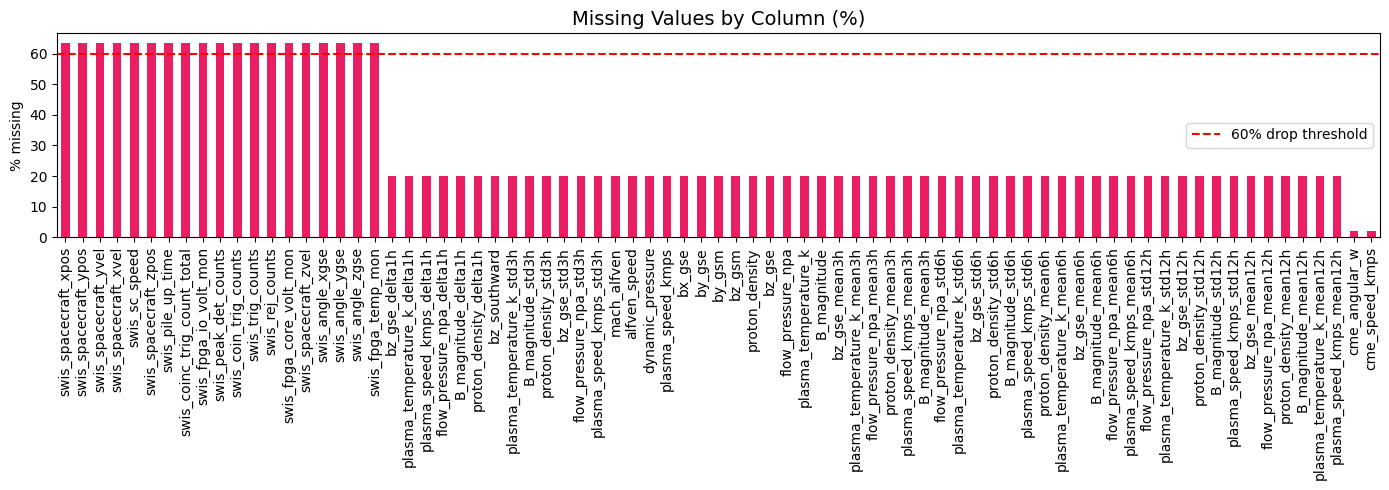

In [28]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = df.isnull().mean().sort_values(ascending=False) * 100
print('Top 20 columns by % missing:')
display(missing.head(20).round(2).rename('missing_%').to_frame())

fig, ax = plt.subplots(figsize=(14, 5))
missing[missing > 0].plot(kind='bar', ax=ax, color='#E91E63')
ax.set_title('Missing Values by Column (%)', fontsize=14)
ax.set_ylabel('% missing')
ax.axhline(60, color='red', linestyle='--', label='60% drop threshold')
ax.legend()
plt.tight_layout()
plt.show()

In [39]:
# ── Drop >60% missing, then impute ───────────────────────────────────────────
HIGH_MISS_THRESH = 60
drop_cols = [c for c in missing[missing > HIGH_MISS_THRESH].index
             if c not in ['cme_label', 'is_halo']]
df.drop(columns=drop_cols, inplace=True, errors='ignore')
print(f'Dropped {len(drop_cols)} high-missing columns: {drop_cols}')

feat_cols = [c for c in df.columns
             if c not in ['cme_label', 'is_halo', 'cme_speed_kmps', 'cme_angular_w']]

df[feat_cols] = df[feat_cols].ffill().bfill()
df[feat_cols] = df[feat_cols].fillna(df[feat_cols].median())

print(f'Remaining NaN after imputation: {df[feat_cols].isnull().sum().sum()}')

Dropped 19 high-missing columns: ['swis_spacecraft_xpos', 'swis_spacecraft_ypos', 'swis_spacecraft_yvel', 'swis_spacecraft_xvel', 'swis_sc_speed', 'swis_spacecraft_zpos', 'swis_pile_up_time', 'swis_coinc_trig_count_total', 'swis_fpga_io_volt_mon', 'swis_peak_det_counts', 'swis_coin_trig_counts', 'swis_trig_counts', 'swis_rej_counts', 'swis_fpga_core_volt_mon', 'swis_spacecraft_zvel', 'swis_angle_xgse', 'swis_angle_ygse', 'swis_angle_zgse', 'swis_fpga_temp_mon']
Remaining NaN after imputation: 0


In [40]:
# ── Class balance ─────────────────────────────────────────────────────────────
label_dist = df['cme_label'].value_counts(normalize=True).sort_index()
print('Class balance (hourly grid):')
print(label_dist.rename({0: 'non-CME', 1: 'CME'}))
print(f'Imbalance ratio: {label_dist[0]/label_dist.get(1, 1):.1f}:1')

Class balance (hourly grid):
cme_label
non-CME   0.8662
CME       0.1338
Name: proportion, dtype: float64
Imbalance ratio: 6.5:1


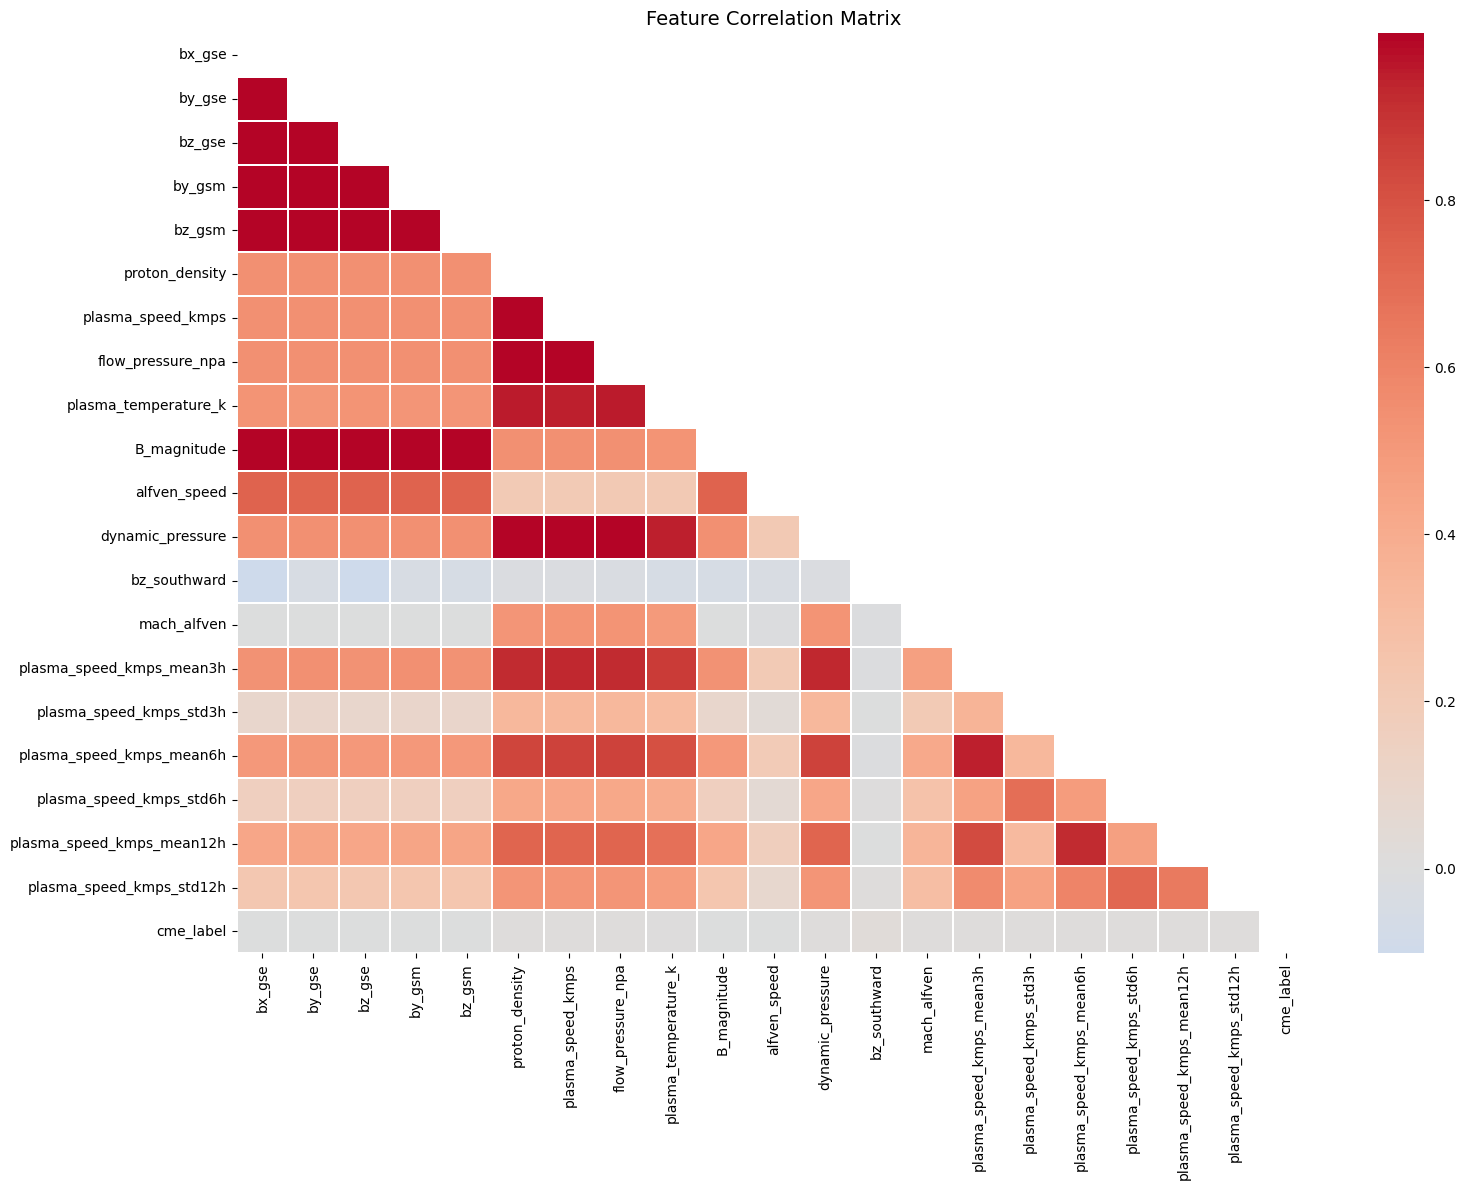


Top 15 features by |corr| with cme_label:


,|corr|
bz_southward,0.0279
plasma_speed_kmps_std6h,0.0151
mach_alfven,0.0147
plasma_speed_kmps_mean3h,0.0141
proton_density,0.0140
plasma_speed_kmps_mean6h,0.0140
plasma_speed_kmps,0.0139
plasma_speed_kmps_std3h,0.0138
plasma_speed_kmps_mean12h,0.0129
dynamic_pressure,0.0128


In [31]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
key_feats = feat_cols[:20]
corr_df   = df[key_feats + ['cme_label']].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.3, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

cme_corr = corr_df['cme_label'].drop('cme_label').abs().sort_values(ascending=False)
print('\nTop 15 features by |corr| with cme_label:')
display(cme_corr.head(15).round(4).rename('|corr|').to_frame())

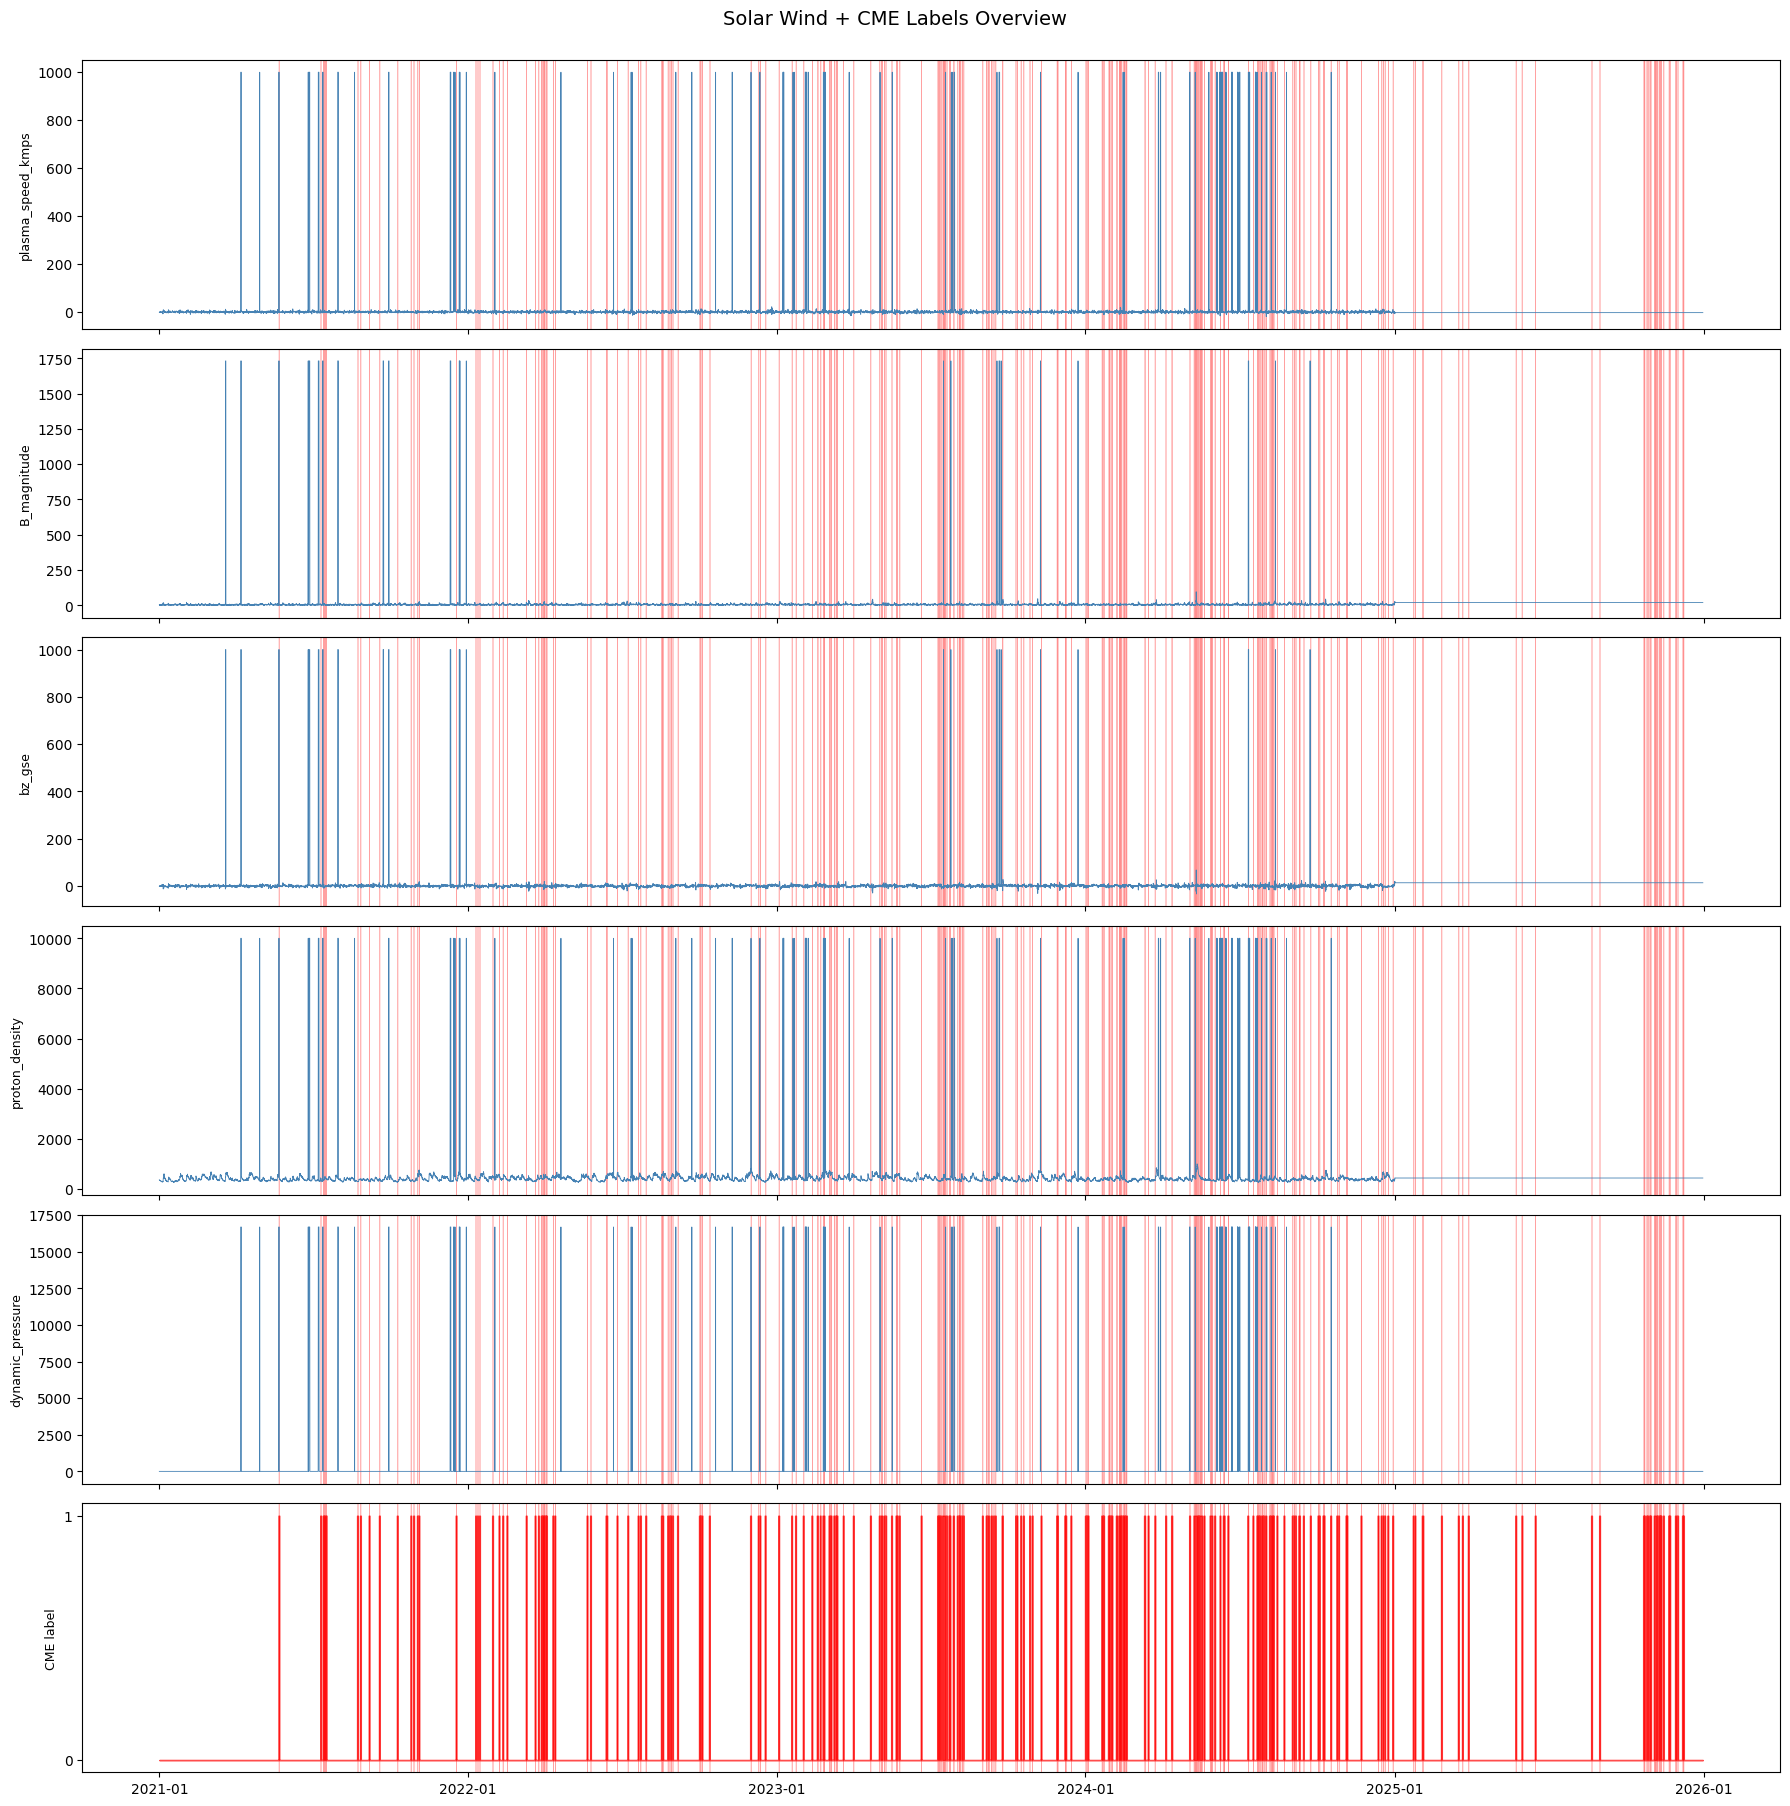

In [32]:
# ── Time-series overview ──────────────────────────────────────────────────────
plot_vars = [c for c in ['plasma_speed_kmps', 'B_magnitude', 'bz_gse',
                          'proton_density', 'dynamic_pressure'] if c in df.columns]
n = len(plot_vars)
fig, axes = plt.subplots(n + 1, 1, figsize=(18, 3 * (n + 1)), sharex=True)

cme_times = df[df['cme_label'] == 1].index
for ax in axes:
    for t in cme_times[::6]:
        ax.axvline(t, color='red', alpha=0.15, linewidth=0.5)

for i, var in enumerate(plot_vars):
    axes[i].plot(df.index, df[var], lw=0.6, color='steelblue')
    axes[i].set_ylabel(var, fontsize=9)

axes[-1].fill_between(df.index, 0, df['cme_label'], step='mid', color='red', alpha=0.7)
axes[-1].set_ylabel('CME label', fontsize=9)
axes[-1].set_yticks([0, 1])
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.suptitle('Solar Wind + CME Labels Overview', fontsize=14, y=1.001)
plt.tight_layout()
plt.show()

---
## 6 — Train / Validation / Test Split (Chronological)

In [33]:
# ── Feature / label columns ───────────────────────────────────────────────────
LABEL_COLS   = ['cme_label', 'is_halo', 'cme_speed_kmps', 'cme_angular_w']
FEATURE_COLS = [c for c in df.columns if c not in LABEL_COLS]
print(f'Total features: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Total features: 57
['bx_gse', 'by_gse', 'bz_gse', 'by_gsm', 'bz_gsm', 'proton_density', 'plasma_speed_kmps', 'flow_pressure_npa', 'plasma_temperature_k', 'B_magnitude', 'alfven_speed', 'dynamic_pressure', 'bz_southward', 'mach_alfven', 'plasma_speed_kmps_mean3h', 'plasma_speed_kmps_std3h', 'plasma_speed_kmps_mean6h', 'plasma_speed_kmps_std6h', 'plasma_speed_kmps_mean12h', 'plasma_speed_kmps_std12h', 'plasma_speed_kmps_delta1h', 'B_magnitude_mean3h', 'B_magnitude_std3h', 'B_magnitude_mean6h', 'B_magnitude_std6h', 'B_magnitude_mean12h', 'B_magnitude_std12h', 'B_magnitude_delta1h', 'proton_density_mean3h', 'proton_density_std3h', 'proton_density_mean6h', 'proton_density_std6h', 'proton_density_mean12h', 'proton_density_std12h', 'proton_density_delta1h', 'bz_gse_mean3h', 'bz_gse_std3h', 'bz_gse_mean6h', 'bz_gse_std6h', 'bz_gse_mean12h', 'bz_gse_std12h', 'bz_gse_delta1h', 'flow_pressure_npa_mean3h', 'flow_pressure_npa_std3h', 'flow_pressure_npa_mean6h', 'flow_pressure_npa_std6h', 'flow_pres

In [34]:
# ── 70 / 15 / 15 chronological split ─────────────────────────────────────────
n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

for name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    pos = split['cme_label'].mean()
    print(f'{name:6s}: {len(split):>7,} rows  '
          f'({split.index.min().date()} → {split.index.max().date()})  '
          f'CME rate={pos:.2%}')

train :  30,659 rows  (2021-01-01 → 2024-07-01)  CME rate=13.35%
val   :   6,571 rows  (2024-07-01 → 2025-04-01)  CME rate=17.33%
test  :   6,570 rows  (2025-04-01 → 2025-12-30)  CME rate=9.57%


In [35]:
# ── StandardScaler — fit on train only ───────────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(train_df[FEATURE_COLS])
X_val   = scaler.transform(val_df[FEATURE_COLS])
X_test  = scaler.transform(test_df[FEATURE_COLS])

y_train = train_df['cme_label'].values
y_val   = val_df['cme_label'].values
y_test  = test_df['cme_label'].values

print('X_train:', X_train.shape, ' y_train:', y_train.shape)
print('X_val  :', X_val.shape,   ' y_val  :', y_val.shape)
print('X_test :', X_test.shape,  ' y_test :', y_test.shape)

X_train: (30659, 57)  y_train: (30659,)
X_val  : (6571, 57)  y_val  : (6571,)
X_test : (6570, 57)  y_test : (6570,)


---
## 7 — Export Processed Datasets

In [36]:
# 1) Full merged dataset
df.to_csv(PROC_DIR / 'full_merged_dataset.csv')
print('Saved: full_merged_dataset.csv')

# 2) Per-split CSVs (un-scaled)
train_df.to_csv(PROC_DIR / 'train.csv')
val_df.to_csv(PROC_DIR   / 'val.csv')
test_df.to_csv(PROC_DIR   / 'test.csv')
print('Saved: train.csv, val.csv, test.csv')

# 3) Scaled numpy arrays
for name, arr in [('X_train', X_train), ('X_val', X_val), ('X_test', X_test),
                  ('y_train', y_train), ('y_val', y_val), ('y_test', y_test)]:
    np.save(PROC_DIR / f'{name}.npy', arr)
print('Saved: X/y train/val/test .npy arrays')

# 4) Scaler
with open(PROC_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Saved: scaler.pkl')

# 5) Feature list
pd.Series(FEATURE_COLS, name='feature').to_csv(PROC_DIR / 'feature_list.csv', index=False)
print('Saved: feature_list.csv')

print(f'\n✅ All outputs written to: {PROC_DIR}')

Saved: full_merged_dataset.csv
Saved: train.csv, val.csv, test.csv
Saved: X/y train/val/test .npy arrays
Saved: scaler.pkl
Saved: feature_list.csv

✅ All outputs written to: D:\SOLAR-HALOS-FORECASTING&NOWCASTING\Project-Code\Dataset\processed


In [37]:
# ── Final summary ─────────────────────────────────────────────────────────────
print('=' * 60)
print('PREPROCESSING COMPLETE — SUMMARY')
print('=' * 60)
print(f'Total samples (hourly): {len(df):,}')
print(f'Feature count:          {len(FEATURE_COLS)}')
print(f'CME positive rate:      {df["cme_label"].mean():.2%}')
print(f'Halo-CME rate:          {df["is_halo"].mean():.2%}')
print(f'Train/Val/Test:         {len(train_df):,} / {len(val_df):,} / {len(test_df):,}')
print(f'Outputs:                {PROC_DIR}')
print()
for i, c in enumerate(FEATURE_COLS, 1):
    print(f'  {i:3d}. {c}')

PREPROCESSING COMPLETE — SUMMARY
Total samples (hourly): 43,800
Feature count:          57
CME positive rate:      13.38%
Halo-CME rate:          13.38%
Train/Val/Test:         30,659 / 6,571 / 6,570
Outputs:                D:\SOLAR-HALOS-FORECASTING&NOWCASTING\Project-Code\Dataset\processed

    1. bx_gse
    2. by_gse
    3. bz_gse
    4. by_gsm
    5. bz_gsm
    6. proton_density
    7. plasma_speed_kmps
    8. flow_pressure_npa
    9. plasma_temperature_k
   10. B_magnitude
   11. alfven_speed
   12. dynamic_pressure
   13. bz_southward
   14. mach_alfven
   15. plasma_speed_kmps_mean3h
   16. plasma_speed_kmps_std3h
   17. plasma_speed_kmps_mean6h
   18. plasma_speed_kmps_std6h
   19. plasma_speed_kmps_mean12h
   20. plasma_speed_kmps_std12h
   21. plasma_speed_kmps_delta1h
   22. B_magnitude_mean3h
   23. B_magnitude_std3h
   24. B_magnitude_mean6h
   25. B_magnitude_std6h
   26. B_magnitude_mean12h
   27. B_magnitude_std12h
   28. B_magnitude_delta1h
   29. proton_density_mean3h